In [1]:
#Goal
# To build a baseline regrssion model with core features and visualize the results.

In [2]:
# import necessary modules

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')


In [3]:

# load the dataset
df = pd.read_csv("combined_solar_radiation.csv")
print(df.head(10))

   Year  Month  Day  Hour  Minute  DHI  DNI  GHI  Clearsky DHI  Clearsky DNI  \
0  2000      1    1     0       0    0    0    0             0             0   
1  2000      1    1     1       0    0    0    0             0             0   
2  2000      1    1     2       0    0    0    0             0             0   
3  2000      1    1     3       0    0    0    0             0             0   
4  2000      1    1     4       0    0    0    0             0             0   
5  2000      1    1     5       0    0    0    0             0             0   
6  2000      1    1     6       0    0    0    0             2             7   
7  2000      1    1     7       0   65  313  114            59           386   
8  2000      1    1     8       0  102  594  302           100           650   
9  2000      1    1     9       0  129  747  489           122           773   

   ...  Temperature  Pressure  Relative Humidity  Solar Zenith Angle  \
0  ...            5       890              83.3

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131496 entries, 0 to 131495
Data columns (total 22 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Year                131496 non-null  int64  
 1   Month               131496 non-null  int64  
 2   Day                 131496 non-null  int64  
 3   Hour                131496 non-null  int64  
 4   Minute              131496 non-null  int64  
 5   DHI                 131496 non-null  int64  
 6   DNI                 131496 non-null  int64  
 7   GHI                 131496 non-null  int64  
 8   Clearsky DHI        131496 non-null  int64  
 9   Clearsky DNI        131496 non-null  int64  
 10  Clearsky GHI        131496 non-null  int64  
 11  Dew Point           131496 non-null  int64  
 12  Temperature         131496 non-null  int64  
 13  Pressure            131496 non-null  int64  
 14  Relative Humidity   131496 non-null  float64
 15  Solar Zenith Angle  131496 non-nul

In [5]:
# display summary statistics
print(df.describe())

                Year          Month            Day           Hour    Minute  \
count  131496.000000  131496.000000  131496.000000  131496.000000  131496.0   
mean     2006.999270       6.522723      15.730243      11.500000       0.0   
std         4.320707       3.448773       8.800381       6.922213       0.0   
min      2000.000000       1.000000       1.000000       0.000000       0.0   
25%      2003.000000       4.000000       8.000000       5.750000       0.0   
50%      2007.000000       7.000000      16.000000      11.500000       0.0   
75%      2011.000000      10.000000      23.000000      17.250000       0.0   
max      2014.000000      12.000000      31.000000      23.000000       0.0   

                 DHI            DNI            GHI   Clearsky DHI  \
count  131496.000000  131496.000000  131496.000000  131496.000000   
mean       92.885593     179.538503     211.019666      75.107730   
std       120.882359     277.967916     292.640651      89.936189   
min         

In [6]:
print(df.isnull().sum())

Year                  0
Month                 0
Day                   0
Hour                  0
Minute                0
DHI                   0
DNI                   0
GHI                   0
Clearsky DHI          0
Clearsky DNI          0
Clearsky GHI          0
Dew Point             0
Temperature           0
Pressure              0
Relative Humidity     0
Solar Zenith Angle    0
Precipitable Water    0
Snow Depth            0
Wind Direction        0
Wind Speed            0
Fill Flag             0
SourceFile            0
dtype: int64


In [7]:
# DATA PREPROCESSING

In [8]:

# Convert date and time columns to datetime
df["Datetime"]= pd.to_datetime(df[['Year', 'Month', 'Day', 'Hour', 'Minute']])

# Extract the time-based fatures
df['Hour_of_Day'] = df['Hour'] 
df['Day_of_Year'] = df['Datetime'].dt.dayofyear

#Create cyclic time encodning for circular nature of time
df['Hour_sin'] = np.sin(2 * np.pi * df['Hour_of_Day'] / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Hour_of_Day'] / 24)
df['Day_sin'] = np.sin(2 * np.pi * df['Day_of_Year'] / 365.25)
df['Day_cos'] = np.cos(2 * np.pi * df['Day_of_Year'] / 365.25)

In [9]:
# Filter daytime hours (GHI > 0)
initial_state = len(df)
df_daytime = df[df['GHI'] > 0]
df = df[df['GHI'] > 0 ].copy()
removed = initial_state - len(df)
print(f"Removed {removed} nighttime records. Remaining records: {len(df)}")

Removed 66031 nighttime records. Remaining records: 65465


In [10]:
# CREATE TARGET VARIABLES

In [11]:
# Solar panel specifications
Panel_efficiency = 0.18  # 18% efficiency for modern standard panels
Panel_ares = 1000 #in metres squared
Temp_coefficient = -0.004  # Efficiency drops by 0.4% per degree Celsius above 25°C


In [12]:
#calculate temperature loss factor
df['Temp_loss_factor'] = 1 + Temp_coefficient * (df['Temperature'] - 25)
#calculate Power output
df['Power_Output'] = df['GHI'] * Panel_ares * Panel_efficiency * df['Temp_loss_factor'] / 1000  # in kW 

#ensure no negative power output
df['power_output'] = df['Power_Output'].clip(lower=0)

In [13]:
# Power Output Statistics
print(f"\nPower Output Statistics:")
print(f"  • Mean:   {df['Power_Output'].mean():.2f} kW")
print(f"  • Median: {df['Power_Output'].median():.2f} kW")
print(f"  • Max:    {df['Power_Output'].max():.2f} kW")
print(f"  • Min:    {df['Power_Output'].min():.2f} kW")
print(f"  • Std:    {df['Power_Output'].std():.2f} kW")


Power Output Statistics:
  • Mean:   77.71 kW
  • Median: 76.02 kW
  • Max:    180.51 kW
  • Min:    0.18 kW
  • Std:    51.91 kW


In [14]:
# FEATURE SELECTION

In [15]:

core_features = [
    'GHI',                  # Primary predictor
    'DNI',                  # Direct irradiance
    'Temperature',          # Panel efficiency factor
    'Solar Zenith Angle',   # Sun position
    'Day_of_Year',          # Seasonal pattern
    'Hour_of_Day'           # Diurnal pattern
]
available_features = [f for f in core_features if f in df.columns]

print(f"Core Features ({len(available_features)} selected):")
for i, feature in enumerate(available_features, 1):
    print(f"  {i}. {feature}")

X = df[available_features]
y = df['Power_Output']

print(f"\n✓ Features matrix: {X.shape}")
print(f"✓ Target vector: {y.shape}")

Core Features (6 selected):
  1. GHI
  2. DNI
  3. Temperature
  4. Solar Zenith Angle
  5. Day_of_Year
  6. Hour_of_Day

✓ Features matrix: (65465, 6)
✓ Target vector: (65465,)


In [16]:
# TRAIN-TEST SPLIT

In [17]:
# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print(f"✓ Train-Test Split Completed:")
print(f"  • Training set:   {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  • Test set:       {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"  • Features used:  {X_train.shape[1]}")
print(f"  • Random state:   42 (for reproducibility)")

✓ Train-Test Split Completed:
  • Training set:   52,372 samples (80.0%)
  • Test set:       13,093 samples (20.0%)
  • Features used:  6
  • Random state:   42 (for reproducibility)


In [18]:
# FEATURE SCALING
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Show scaling parameters
scaling_params = pd.DataFrame({
    'Feature': available_features,
    'Mean': scaler.mean_,
    'Std': scaler.scale_
})
print(f"\n Scaling Parameters:")
print(scaling_params.to_string(index=False))



 Scaling Parameters:
           Feature       Mean        Std
               GHI 424.273963 286.233170
               DNI 361.444016 299.810353
       Temperature  18.743050   4.854228
Solar Zenith Angle  53.587246  21.320909
       Day_of_Year 182.030417 100.424876
       Hour_of_Day  11.324715   3.517275


In [19]:
# TRAIN LINEAR REGRESSION MODEL

In [20]:
# Initialize and train model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Make predictions
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

print(" Model training completed!")
print(f" Model type: Linear Regression")
print(f" Intercept: {model.intercept_:.2f}")
print(f" Coefficients: {len(model.coef_)} parameters")


 Model training completed!
 Model type: Linear Regression
 Intercept: 77.79
 Coefficients: 6 parameters


In [21]:
# MODEL EVALUATION

In [22]:
# Calculate metrics
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

In [23]:
# PERFORMANCE METRICS
print("\n1. R² Score (Coefficient of Determination):")
print(f"   Train R²: {train_r2:.4f}")
print(f"   Test R²:  {test_r2:.4f}")
print(f"   Model explains {test_r2*100:.2f}% of variance in solar output")

print("\n2. Mean Squared Error (MSE):")
print(f"   Train MSE: {train_mse:.2f} kW²")
print(f"   Test MSE:  {test_mse:.2f} kW²")

print("\n3. Root Mean Squared Error (RMSE):")
print(f"   Train RMSE: {train_rmse:.2f} kW")
print(f"   Test RMSE:  {test_rmse:.2f} kW")
print(f"   Average prediction error: ±{test_rmse:.2f} kW")

print("\n4. Mean Absolute Error (MAE):")
print(f"   Test MAE: {test_mae:.2f} kW")
print(f"   Average absolute error: {test_mae:.2f} kW")


1. R² Score (Coefficient of Determination):
   Train R²: 0.9997
   Test R²:  0.9997
   Model explains 99.97% of variance in solar output

2. Mean Squared Error (MSE):
   Train MSE: 0.94 kW²
   Test MSE:  0.94 kW²

3. Root Mean Squared Error (RMSE):
   Train RMSE: 0.97 kW
   Test RMSE:  0.97 kW
   Average prediction error: ±0.97 kW

4. Mean Absolute Error (MAE):
   Test MAE: 0.71 kW
   Average absolute error: 0.71 kW


In [24]:
# Overfitting check
r2_diff = train_r2 - test_r2
print("\n" + "-" * 80)
print("🔍 OVERFITTING ANALYSIS:")
print(f"   R² difference (Train - Test): {r2_diff:.4f}")

if r2_diff < 0.02:
    verdict = "✓ Excellent - No overfitting detected"
elif r2_diff < 0.05:
    verdict = "✓ Good - Minimal overfitting"
elif r2_diff < 0.10:
    verdict = "⚠ Acceptable - Slight overfitting"
else:
    verdict = "✗ Warning - Significant overfitting detected"

print(f"   {verdict}")


--------------------------------------------------------------------------------
🔍 OVERFITTING ANALYSIS:
   R² difference (Train - Test): 0.0000
   ✓ Excellent - No overfitting detected


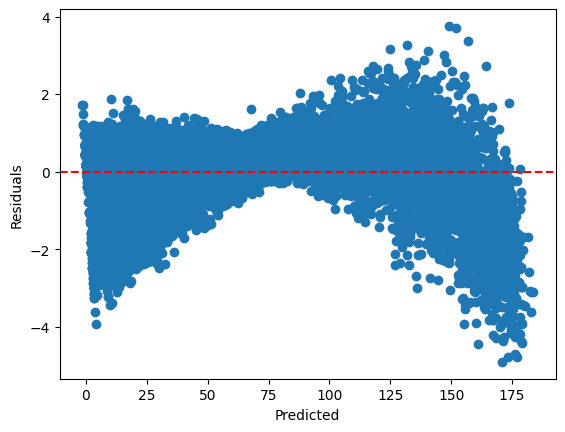

In [25]:
residuals = y_test - y_test_pred
plt.scatter(y_test_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()


In [27]:
# Feature importance

feature_importance = pd.DataFrame({
    'Feature': available_features,
    'Coefficient': model.coef_,
    'Abs_Coefficient': np.abs(model.coef_)
}).sort_values('Abs_Coefficient', ascending=False)

print(feature_importance[['Feature', 'Coefficient']].to_string(index=False))



           Feature  Coefficient
               GHI    51.309044
       Temperature    -1.269142
               DNI     0.914756
Solar Zenith Angle    -0.611103
       Day_of_Year     0.054724
       Hour_of_Day     0.007910


In [28]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

Text(0.05, 0.95, 'R² = 0.9997')

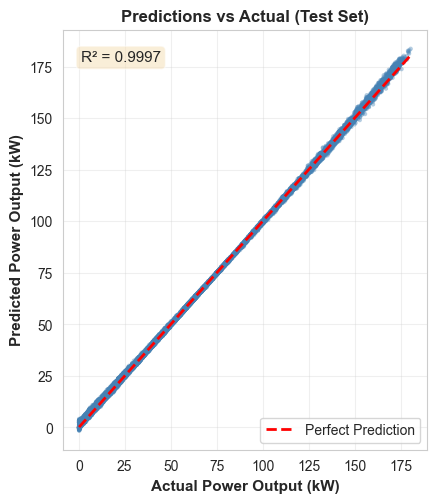

In [29]:
fig = plt.figure(figsize=(16, 12))

# 1. Predictions vs Actual (Test Set)
ax1 = plt.subplot(2, 3, 1)
ax1.scatter(y_test, y_test_pred, alpha=0.4, s=10, c='steelblue', edgecolors='none')
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect Prediction')
ax1.set_xlabel('Actual Power Output (kW)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Predicted Power Output (kW)', fontsize=11, fontweight='bold')
ax1.set_title('Predictions vs Actual (Test Set)', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.text(0.05, 0.95, f'R² = {test_r2:.4f}', transform=ax1.transAxes, 
         fontsize=11, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))


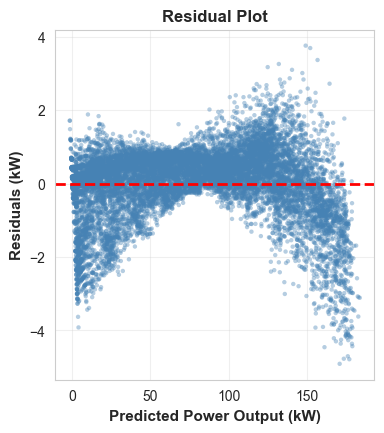

In [30]:
# 2. Residual Plot
ax2 = plt.subplot(2, 3, 2)
residuals = y_test - y_test_pred
ax2.scatter(y_test_pred, residuals, alpha=0.4, s=10, c='steelblue', edgecolors='none')
ax2.axhline(y=0, color='r', linestyle='--', lw=2)
ax2.set_xlabel('Predicted Power Output (kW)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Residuals (kW)', fontsize=11, fontweight='bold')
ax2.set_title('Residual Plot', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

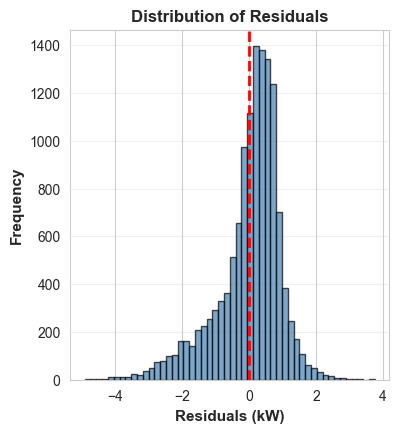

In [31]:
# 3. Residual Distribution
ax3 = plt.subplot(2, 3, 3)
ax3.hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax3.axvline(x=0, color='r', linestyle='--', lw=2)
ax3.set_xlabel('Residuals (kW)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax3.set_title('Distribution of Residuals', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

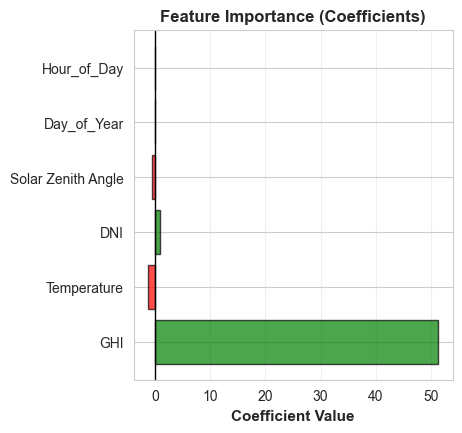

In [32]:
# 4. Feature Importance
ax4 = plt.subplot(2, 3, 4)
colors = ['green' if c > 0 else 'red' for c in feature_importance['Coefficient']]
bars = ax4.barh(feature_importance['Feature'], feature_importance['Coefficient'], 
                color=colors, alpha=0.7, edgecolor='black')
ax4.axvline(x=0, color='black', linestyle='-', lw=1)
ax4.set_xlabel('Coefficient Value', fontsize=11, fontweight='bold')
ax4.set_title('Feature Importance (Coefficients)', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')

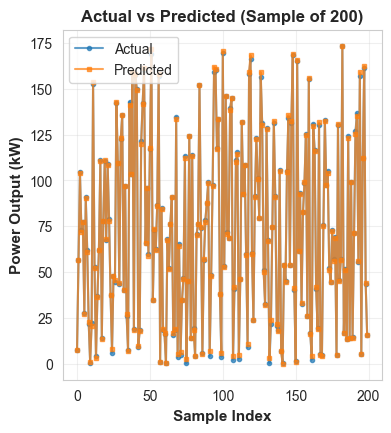

In [33]:
# 5. Actual vs Predicted Time Series (Sample)
ax5 = plt.subplot(2, 3, 5)
sample_size = min(200, len(y_test))
sample_indices = np.random.choice(len(y_test), sample_size, replace=False)
sample_indices = np.sort(sample_indices)
ax5.plot(range(sample_size), y_test.iloc[sample_indices].values, 
         'o-', label='Actual', alpha=0.7, markersize=3)
ax5.plot(range(sample_size), y_test_pred[sample_indices], 
         's-', label='Predicted', alpha=0.7, markersize=3)
ax5.set_xlabel('Sample Index', fontsize=11, fontweight='bold')
ax5.set_ylabel('Power Output (kW)', fontsize=11, fontweight='bold')
ax5.set_title(f'Actual vs Predicted (Sample of {sample_size})', fontsize=12, fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3)

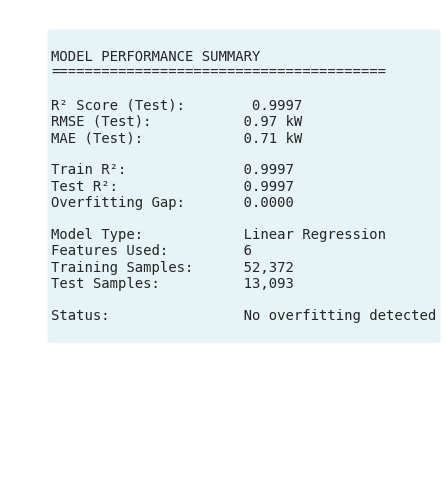

In [34]:
# 6. Error Metrics Summary
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')
metrics_text = f"""
MODEL PERFORMANCE SUMMARY
{'='*40}

R² Score (Test):        {test_r2:.4f}
RMSE (Test):           {test_rmse:.2f} kW
MAE (Test):            {test_mae:.2f} kW

Train R²:              {train_r2:.4f}
Test R²:               {test_r2:.4f}
Overfitting Gap:       {r2_diff:.4f}

Model Type:            Linear Regression
Features Used:         {len(available_features)}
Training Samples:      {len(X_train):,}
Test Samples:          {len(X_test):,}

Status:                {verdict.split('-')[1].strip()}
"""
ax6.text(0.1, 0.95, metrics_text, transform=ax6.transAxes,
         fontsize=10, verticalalignment='top', family='monospace',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

plt.tight_layout()
# plt.savefig('phase1_solar_regression_results.png', dpi=300)
plt.show()